# 4a

The normalization step is desired to ensure that the size of the data does not change when the filter is applied. This is important because, otherwise, the brightness would change when the filter is applied! Without normalization, the image will either get lighter or darker depending on if the weights sume to greater or less than one. Thus, we normalize to ensure that the entires sum to one and thus each output pixel is the weighted average of input pixels.

In [2]:
import numpy as np

def blurfilter(sigma, n=None):
	"""BLURFILTER Creates a Gaussian blur filter.
	FILT = BLURFILTER(SIGMA, N) creates a Gaussian blur filter with
	bandwidth parameter SIGMA, and size N x N. If N isn't specified, it
	defaults to ceil(6*sigma) + 1.

	The output of this function is the filter FILT."""

	if n == None:
		n = int(np.ceil(6*sigma)) + 1
			
	rad = (n - 1)/2
	xs, ys = np.meshgrid(np.linspace(-rad, rad, n), np.linspace(rad, -rad, n))
		
	# Your code here -- (make sure you understand what xs and ys represent!)
	# xs = [-rad, ..., rad] repeated n times as rows
	# ys = [rad, ..., -rad] repeated n times as cols
	# rad = radius of filter (in pixels)
	filter = np.exp(-(xs**2 + ys**2) / (2 * sigma**2))

	filter = filter / np.sum(filter) 
	return filter



# 4b

The fourier transform of a Gaussian is also a Gaussian! Looking at the generated plots, this is clear as day.

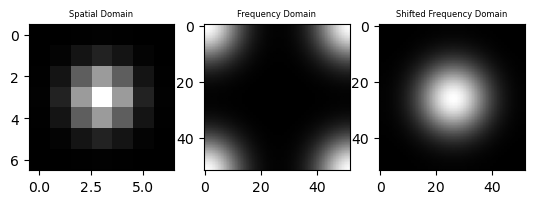

In [46]:
from numpy.fft import fft2
import matplotlib.pyplot as plt

filter_spatial = blurfilter(sigma=1)
vert_dim = filter.shape[0]
horiz_dim = filter.shape[1]
filter_frequency = fft2(filter_spatial, s=(vert_dim*4, horiz_dim*4)) # add padding to improve appearance as instructed
shifted_filter = np.fft.fftshift(filter_frequency) # shift zero freq to center
display_filter = abs(shifted_filter)

fig, axs = plt.subplots(1, 3)

axs[0].set_title("Spatial Domain", fontsize=6)
surf = axs[0].imshow(filter_spatial, cmap="gray")

axs[1].set_title("Frequency Domain", fontsize=6)
surf = axs[1].imshow(abs(filter_frequency), cmap="gray")

axs[2].set_title("Shifted Frequency Domain", fontsize=6)
surf = axs[2].imshow(display_filter, cmap="gray")

# 4c

Here we have demonstrated that the pointwise product in the fruency domain is the same as convolution in the spatial domain! The output is the same result! This relates directly to what we have shown in 4a (and what we proved in problem 3) because the fft of the gaussian is also a gaussian. Notice how the third plot, the difference one, shows absolutely no difference between the spatial convolution and the frequency convolution!

(np.float64(-0.5), np.float64(511.5), np.float64(479.5), np.float64(-0.5))

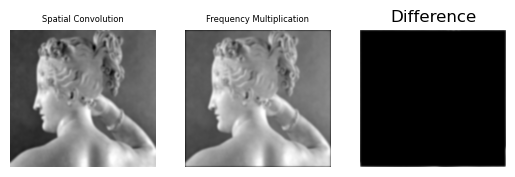

In [ ]:
from scipy.ndimage import convolve
from PIL import Image

image = 'Paolina-2.tiff'
im = np.array(Image.open(image))

im = im.astype('float')/255
x_dim, y_dim = im.shape

sigma = 3
shape_image = im.shape
filter = blurfilter(sigma=sigma)
shape_filter = filter.shape
padding_size = (shape_image[0] + shape_filter[0] - 1, shape_image[1] + shape_filter[1] - 1)


blurred_im = convolve(im, filter, mode='reflect')

fft_im = fft2(im, s=padding_size)
fft_filter = fft2(filter, s=padding_size)

fft_blurred = fft_im * fft_filter
blurred_im_fft = np.fft.ifft2(fft_blurred).real # gotta use .real to get rid of tiny imaginary parts due to numerical error

# crop out padding b/f plotting
blurred_im_fft = blurred_im_fft[shape_filter[0]//2:shape_filter[0]//2 + x_dim, 
                                shape_filter[1]//2:shape_filter[1]//2 + y_dim]

fig, axs = plt.subplots(1, 3)
axs[0].set_title("Spatial Convolution", fontsize=6)
axs[0].imshow(blurred_im, cmap='gray')
axs[0].axis('off')
axs[1].set_title("Frequency Multiplication", fontsize=6)
axs[1].imshow(blurred_im_fft, cmap='gray')
axs[1].axis('off')
axs[2].set_title("Difference")
difference = np.abs(blurred_im - blurred_im_fft)
axs[2].imshow(difference, cmap='gray')
axs[2].axis('off')

# 4d

Difference of gaussians performs feature enhancement by subtracting a blurred version of an image from a less blurred version. It preserves features that fall between two different levels of blur. This is crucial because it lets us filter out high frequency noise and fine details. If we look at the application of the dog filter to steve and loki, we witness this exact behavior. The boundaries and contours are highlighted in both images and the uniform regions, like the backdrop for loki, become zero. This is the mexican hat behavior that we discussed in lecture, w/ positive center nad negative surround, which we can clearly see in the plot of the filter below.

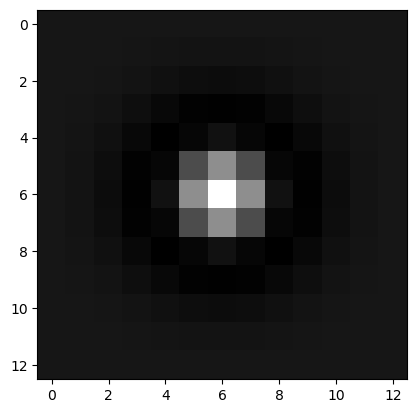

In [64]:
filter_one = blurfilter(sigma=1, n=13)
filter_two = blurfilter(sigma=2, n=13)
filter_one = (filter_one / np.sum(filter_one)) 
filter_two = (filter_two / np.sum(filter_two))

dog_filter = filter_one - filter_two
dog_filter = dog_filter - np.mean(dog_filter)

plt.imshow(dog_filter, cmap='gray')

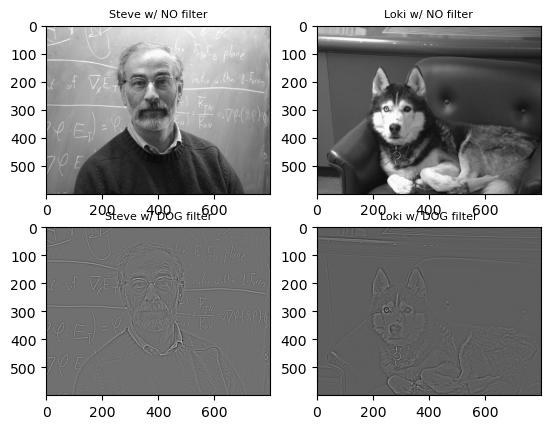

In [63]:
image_loki = "Loki.tiff"
image_steve = "Steve.tiff"
im_loki = np.array(Image.open(image_loki))
im_loki = im_loki.astype('float')/255
im_steve = np.array(Image.open(image_steve))
im_steve = im_steve.astype('float')/255

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax1.set_title("Steve w/ NO filter", fontsize=8)
ax1.imshow(im_steve, cmap='gray')
ax2.set_title("Loki w/ NO filter", fontsize=8)
ax2.imshow(im_loki, cmap='gray')

loki_filter = convolve(im_loki, dog_filter)
steve_filter = convolve(im_steve, dog_filter)

ax3.set_title("Steve w/ DOG filter", fontsize=8)
ax3.imshow(steve_filter, cmap='gray')
ax4.set_title("Loki w/ DOG filter", fontsize=8)
ax4.imshow(loki_filter, cmap='gray')

# 4e

This is a band pass filter, and that can be clearly seen in the plot because the center is dark, surrounded by a light ring and finally fading back to dark. Thus, the low frequencies (middle section) are suppressed aswell as the high freqiencies. Frequencies composing the middle ring, medium frequencies, survive and are enhanced. Thus, the 2d fourier transform of this filter is a band pass! 

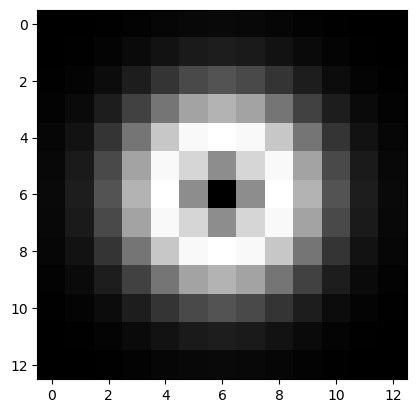

In [28]:
fft = fft2(dog_filter)
shifted_fft = np.fft.fftshift(fft)

plt.imshow(abs(shifted_fft), cmap='gray')

# 4f

The unsharp filter mask appears to be sharpening the image! It seems like its enhancing the high freqiencies while preserving the low frequencies at the same time. This makes sense if we think through the steps of the unsharpmask. We begin by computing the mask (image - blurred) which extracts out the high frequency details. The filtered output is the original image multiplied by the mask times a scaling factor amount. Thus, we are essentially adding back those details amplified by said scaling factor! Thus, we see a sharpened image.

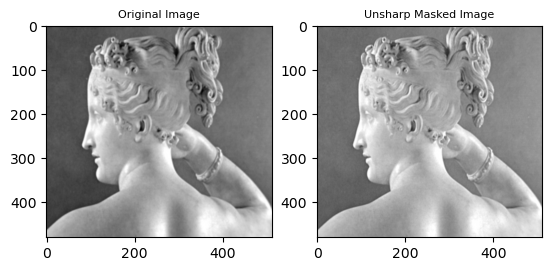

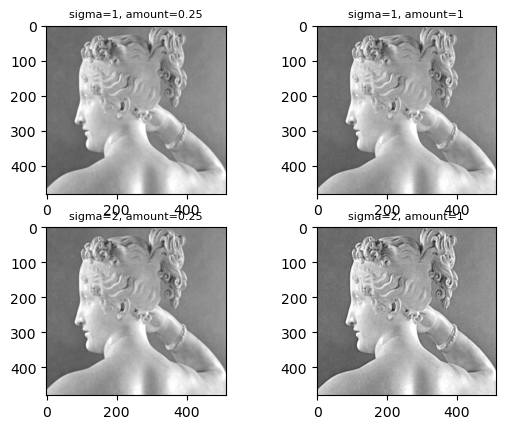

In [40]:
def unsharpmask(img, sigma, amount):
   """UNSHARPMASK Perform unsharp masking on an image.
   FILTERED = UNSHARPMASK(IMG, SIGMA, AMOUNT) performs unsharp masking on
   the image IMG, using a blur parameter SIGMA and a strength AMOUNT.
   Unsharp masking consists of:

      1. Blurring the input image;
      2. Forming the "mask" by substracting the blurred image from the
         input image;
      3. Adding the mask, scaled by some amount, back to the input image.

   The output of this function is the filtered image FILTERED."""

   # Your code here
   filter = blurfilter(sigma=sigma)
   blurred = convolve(img, filter, mode="reflect")
   mask = img - blurred
   filtered = img + amount * mask
   return filtered

image = 'Paolina-2.tiff'
im = np.array(Image.open(image))
im = im.astype('float')/255
x_dim, y_dim = im.shape

masked_img = unsharpmask(im, sigma=1, amount=1)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.set_title("Original Image", fontsize=8)
ax1.imshow(im, cmap='gray')
ax2.set_title("Unsharp Masked Image", fontsize=8)
ax2.imshow(masked_img, cmap='gray', vmin=0, vmax=1)

params = [(1, 0.25), (1, 1), (2, 0.25), (2, 1)] # different (sigma, amount) pairs
fig, axs = plt.subplots(2, 2)
for i, (sigma, amount) in enumerate(params):
   masked_img = unsharpmask(im, sigma=sigma, amount=amount)
   ax = axs[i//2, i%2]
   ax.set_title(f"sigma={sigma}, amount={amount}", fontsize=8)
   ax.imshow(masked_img, cmap='gray', vmin=0, vmax=1)
